In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

fig_save_path = "/Users/thomassainsbury/Documents/Mathis_lab/Aug_Reg/AR_plots_new/"

In [2]:
cd ..

/Users/thomassainsbury/Documents/Mathis_lab/Mathis_lab_code/FreelyMovingVR4Mice/dj_pipeline


In [3]:
%run env_tom.py
%run run.py connect

2024-09-17 15:27:55,886::INFO::settings.py::Setting loglevel to INFO
2024-09-17 15:27:55,887::INFO::settings.py::Setting stores to {}
2024-09-17 15:27:55,887::INFO::settings.py::Setting database.misc.schema_prefix to 
2024-09-17 15:27:55,888::INFO::settings.py::Setting database.misc.create_tables to True
2024-09-17 15:27:55,888::INFO::settings.py::Setting enable_python_native_blobs to True
2024-09-17 15:27:55,888::INFO::settings.py::Setting database.host to 128.178.51.167:3309
2024-09-17 15:27:55,889::INFO::settings.py::Setting database.user to thomas
2024-09-17 15:27:55,889::INFO::settings.py::Setting database.password to thomas


Connecting thomas@128.178.51.167:3309


2024-09-17 15:27:56,175::INFO::connection.py::Connected thomas@128.178.51.167:3309
2024-09-17 15:27:56,234::INFO::table.py::could not log event in table ~log
2024-09-17 15:27:56,559::INFO::table.py::could not log event in table ~log


In [4]:
from vr4mice.schema import vr4mice, dlc, base_analysis
import vr4mice.analysis.plotting as plotting
import vr4mice.analysis.utils as utils
import vr4mice.analysis.visual_discrim_functions as vdf
from vr4mice.analysis import regression
vdf.get_rc_params()

In [5]:
dual_occuder = [{"dataset": "Nightingale_2024-08-14_1"},
                {"dataset": "Nightingale_2024-08-13_1"},
                {"dataset": "Nightingale_2024-08-12_1"},
                {"dataset": "Nightingale_2024-08-11_1"},
                {"dataset": "Nightingale_2024-08-10_1"},
                {"dataset": "Lemming_2024-08-13_1"},
                {"dataset": "Lemming_2024-08-12_1"},
                {"dataset": "Lemming_2024-08-11_1"},
                {"dataset": "Lemming_2024-08-10_1"},
                {"dataset": "Jacana_2024-08-13_1"},
                {"dataset": "Jacana_2024-08-14_1"},
                {"dataset": "Jacana_2024-08-15_1"},
                {"dataset": "Jacana_2024-08-16_1"},
                {"dataset": "Jacana_2024-08-19_1"},
                {"dataset": "Kiwi_2024-08-10_2"},
                {"dataset": "Kiwi_2024-08-11_4"},
                {"dataset": "Kiwi_2024-08-12_2"},
                {"dataset": "Kiwi_2024-08-13_1"},
                {"dataset": "Kiwi_2024-08-14_1"},
                {"dataset": "Oribi_2024-08-16_1"},
                {"dataset": "Oribi_2024-08-19_1"},
                {"dataset": "Oribi_2024-08-20_1"},
                {"dataset": "Oribi_2024-08-21_1"},
                {"dataset": "Oribi_2024-08-22_1"},
                {"dataset": "Pheasant_2024-08-15_2"},
                {"dataset": "Pheasant_2024-08-16_1"},
                {"dataset": "Pheasant_2024-08-20_1"},
                {"dataset": "Pheasant_2024-08-21_1"},
               ]


   



In [9]:
def tranform_dlc_centers_to_rig_coords(head_center_x, head_center_y):
    cropped_image=[0, 530, 0, 510]
    unity_arena_size=[-9, 9, -10, -2]
    x = np.interp(np.array(head_center_x, np.float16),
                [cropped_image[0], cropped_image[1]],
                [unity_arena_size[0], unity_arena_size[1]],
            )
    y = np.interp(np.array(head_center_y, np.float16),
                [cropped_image[2], cropped_image[3]],
                [unity_arena_size[2], unity_arena_size[3]],
            )
    x = np.interp(x, [-9, 9], [-27, 27])
    y = np.interp(y, [-10, -2], [-27, 27])
    return(x, y)
    

def get_all_in_list(data_set_list, training_stage="dual_occluder"):
    print(training_stage)
    big_df = []
    day = 0
    for d in data_set_list:
        split_d = d["dataset"].split("_")
        print(split_d)
        df = dlc.SyncDLCWGame().get_data(key =  d)
        df ["mouse_name"] = split_d [0]
        df ["session"] = df ["dataset"]
        df ["date"] = split_d [1]
        df ["training_stage"] = training_stage
        big_df.append(df)
    big_df =  pd.concat(big_df).reset_index()
    big_df = big_df.groupby(["dataset", "trial"],as_index=False).apply(lambda x: x [1:])
    big_df ["session_increment"] = np.array(big_df.groupby(['mouse_name', 'date', "session"]).ngroup()+1)
    big_df ["trial_rewarded"] = big_df.groupby(["mouse_name", "date", "dataset", "trial"], as_index=False)["reward"].transform(
        lambda x: x.max())
    first_n_samples =5
    big_df["norm_x"] = big_df.groupby("trial", as_index=False)["x"].transform(
        lambda x: x - np.mean(x.iloc[:first_n_samples]))
    big_df["norm_y"] = big_df.groupby("trial", as_index=False)["y"].transform(
        lambda x: x - np.mean(x.iloc[:first_n_samples]))
        
    big_df = big_df.groupby(["dataset", "trial"],as_index=False).apply(lambda x: x [1:])
    big_df ["session_increment"] = np.array(big_df.groupby(['mouse_name', 'date', "session"]).ngroup()+1)
    big_df
    big_df ["trial_rewarded"] = big_df.groupby(["mouse_name", "date", "dataset", "trial"], as_index=False)["reward"].transform(
        lambda x: x.max()
    )
    
    right_reward_x = big_df[(big_df.reward > 0.5) & (big_df.trial_right_choice > 0.5)]["x"].mean()
    right_reward_z = big_df[(big_df.reward > 0.5) & (big_df.trial_right_choice > 0.5)]["y"].mean()
    
    big_df["distance_to_reward"] = (np.array(((right_reward_x - big_df["x"] * big_df["flip_one_side"]) ** 2),dtype=np.float64) + 
                                    np.array(((right_reward_z - big_df["y"]) ** 2), dtype=np.float64))
    big_df ["heading_dir"] = ((big_df.heading_dir - 90) + 180) % 360 - 180
    big_df ["head_dir"] = ((big_df.head_dir) + 180) % 360 -180
    big_df = big_df.infer_objects()
    #big_df["velocity"][big_df ["velocity"] > 300] = np.nan
    #big_df["veloctiy"] =big_df["velocity"].interpolate().copy()
    return(big_df.reset_index(drop=True))



In [7]:
def get_j_shaped(big_df):
        # J-shaped trials
    j_shaped = big_df[
        (big_df.trial_duration <= 5) & (big_df.trial_rewarded > 0.5) & (big_df["trial_tortuosity"] <= 5)
    ]

    # stats: percentage of j shaped trials per session
    j_shaped_percentage = (
        j_shaped.groupby(["session"]).trial.nunique().values
        / big_df.groupby(["session"]).trial.nunique().values
    )
    print(j_shaped_percentage.mean(), stats.sem(j_shaped_percentage))
    return(j_shaped)

In [8]:
big_df = get_all_in_list(data_set_list = dual_occuder)


dual_occluder
['Nightingale', '2024-08-14', '1']
['Nightingale', '2024-08-13', '1']
['Nightingale', '2024-08-12', '1']
['Nightingale', '2024-08-11', '1']
['Nightingale', '2024-08-10', '1']
['Lemming', '2024-08-13', '1']
['Lemming', '2024-08-12', '1']
['Lemming', '2024-08-11', '1']
['Lemming', '2024-08-10', '1']
['Jacana', '2024-08-13', '1']
['Jacana', '2024-08-14', '1']
['Jacana', '2024-08-15', '1']
['Jacana', '2024-08-16', '1']
['Jacana', '2024-08-19', '1']
['Kiwi', '2024-08-10', '2']
['Kiwi', '2024-08-11', '4']
['Kiwi', '2024-08-12', '2']
['Kiwi', '2024-08-13', '1']
['Kiwi', '2024-08-14', '1']
['Oribi', '2024-08-16', '1']
['Oribi', '2024-08-19', '1']
['Oribi', '2024-08-20', '1']
['Oribi', '2024-08-21', '1']
['Oribi', '2024-08-22', '1']
['Pheasant', '2024-08-15', '2']
['Pheasant', '2024-08-16', '1']
['Pheasant', '2024-08-20', '1']
['Pheasant', '2024-08-21', '1']


2024-09-17 15:31:26,098::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-09-17 15:31:26,127::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-09-17 15:31:26,222::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-09-17 15:31:26,225::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-09-17 15:31:26,305::INFO::category.py::Using categorical un

                mean       sem
aperture                      
4.3       121.821429  1.891259
12.0      123.821429  2.058055


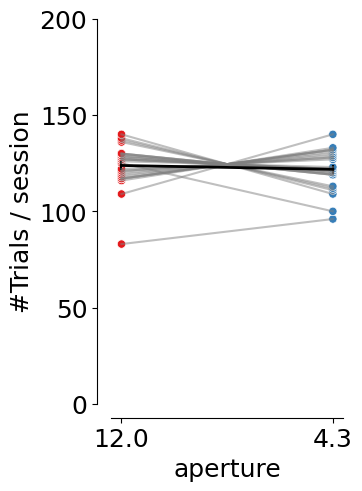

In [10]:
fig,ax = plt.subplots(1,1, figsize = (3,5))
plotting.plot_trial_count(df=big_df, ax=ax, alpha=0.5, per_aperture=True)
plt.ylim(0,200)
sns.despine(offset=10)
plt.savefig(fig_save_path + "dual_occluder_trial_number.svg", transparent=True)

2024-09-17 15:31:27,448::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-09-17 15:31:27,451::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-09-17 15:31:27,466::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-09-17 15:31:27,469::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-09-17 15:31:27,538::INFO::category.py::Using categorical un

              mean       sem
aperture                    
12.0      0.860919  0.014092
4.3       0.796493  0.015558


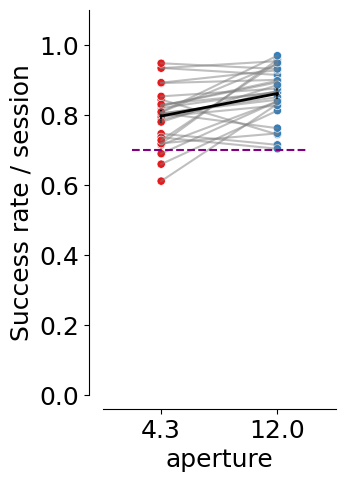

In [11]:
fig,ax = plt.subplots(1,1, figsize = (3,5))
plotting.plot_rewards(df=big_df, ax=ax, alpha=0.5, per_aperture=True)
plt.ylim(0,1.1)
plt.xlim(-0.5,1.5)
sns.despine(offset=10)
plt.savefig(fig_save_path + "dual_occluder_rewards.svg", transparent=True)

In [12]:
j_shaped = get_j_shaped(big_df)
j_shaped = utils.create_bins(data=j_shaped.copy(), spatial_ybins=[6.75, 20, 30], label="y")

0.6690952049752615 0.015922265483501633


In [13]:
mean_mouse = j_shaped.groupby(
    ["session","mouse_name", "training_stage", "date","dataset", "choice", "aperture", "bin_centers"], as_index=False
).mean(numeric_only =True).copy()

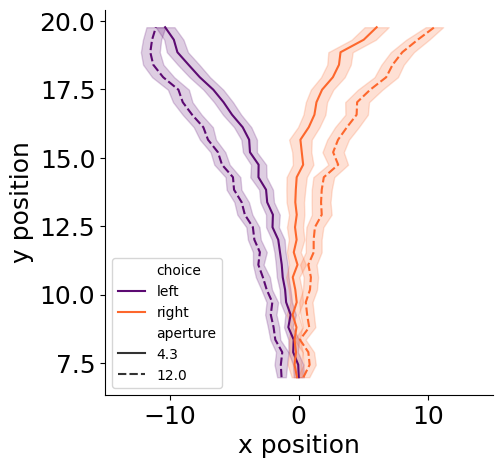

In [14]:
fig, ax = plt.subplots(1,1,figsize=(5,5))
plotting.lineplot_flip_axis(
    data=mean_mouse,
    x="bin_centers",
    y="x",
    hue="choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
    palette=plotting.colors_choice if len(mean_mouse.aperture.unique()) == 2 else "viridis",
    style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "choice",
    errorbar="se",
    ax=ax,
)
plt.ylabel("y position")
plt.xlabel("x position")
plt.xlim(-15,15)
plt.savefig(fig_save_path + "dual_occluder_aperture_mean_traj.svg", transparent=True)

Jacana_2024-08-13_1
Jacana_2024-08-14_1
Jacana_2024-08-15_1
Jacana_2024-08-16_1
Jacana_2024-08-19_1
Kiwi_2024-08-10_2
Kiwi_2024-08-11_4
Kiwi_2024-08-12_2
Kiwi_2024-08-13_1
Kiwi_2024-08-14_1
Lemming_2024-08-10_1
Lemming_2024-08-11_1
Lemming_2024-08-12_1
Lemming_2024-08-13_1
Nightingale_2024-08-10_1
Nightingale_2024-08-11_1
Nightingale_2024-08-12_1
Nightingale_2024-08-13_1
Nightingale_2024-08-14_1
Oribi_2024-08-16_1
Oribi_2024-08-19_1


/var/folders/xx/w02j3bzd5n549z3dmcg59ddw0000gn/T/ipykernel_34210/1146726052.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1,1,figsize=(5,5))


Oribi_2024-08-20_1
Oribi_2024-08-21_1
Oribi_2024-08-22_1
Pheasant_2024-08-15_2
Pheasant_2024-08-16_1
Pheasant_2024-08-20_1
Pheasant_2024-08-21_1


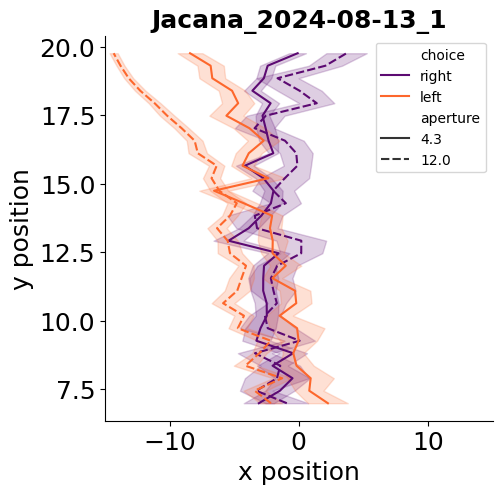

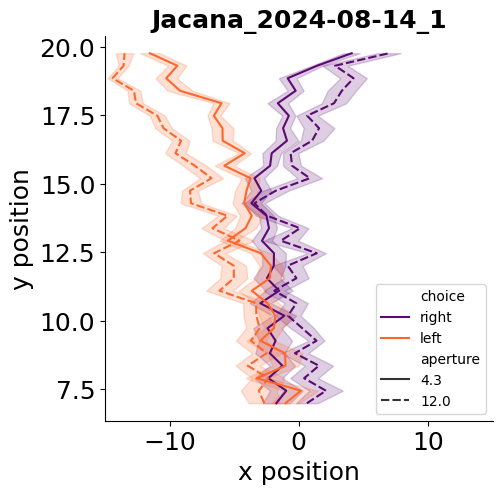

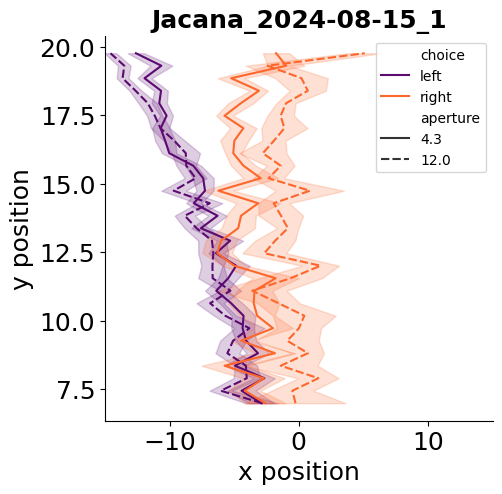

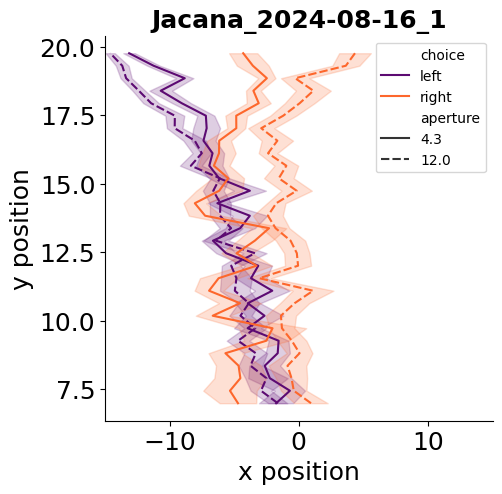

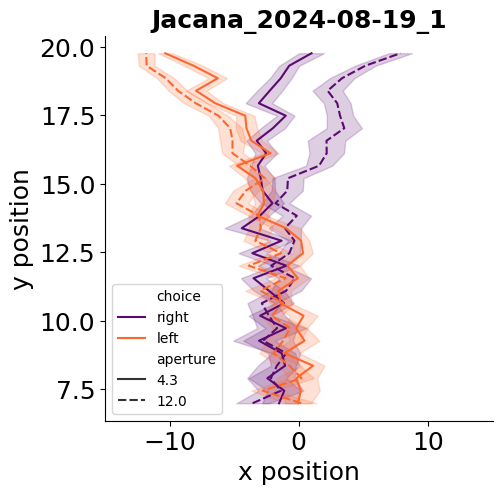

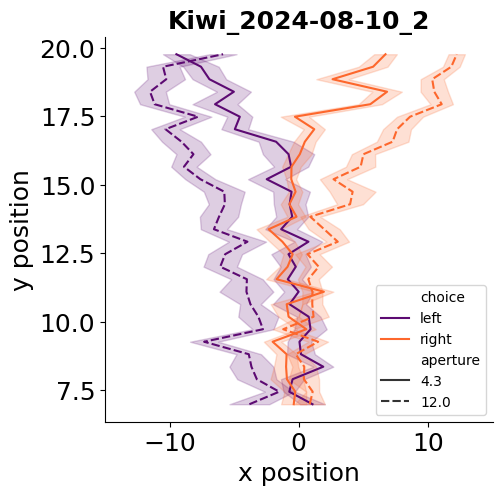

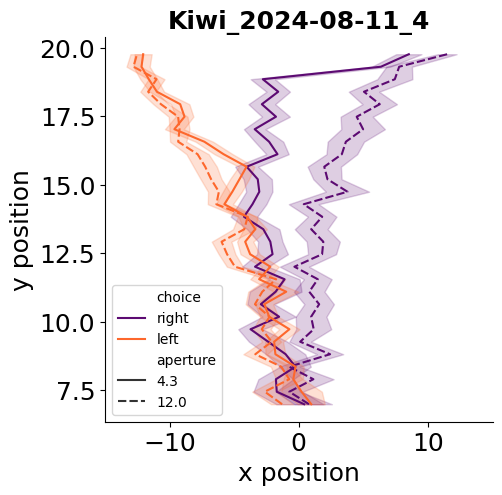

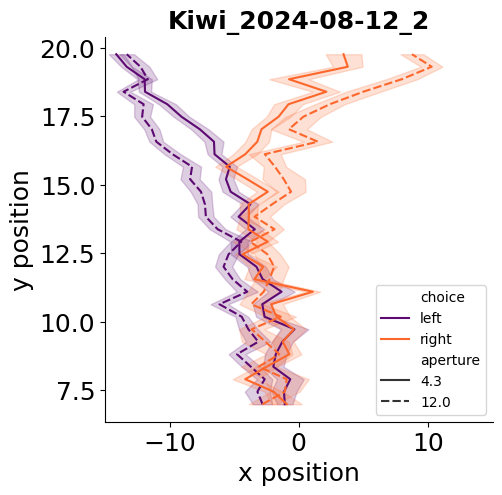

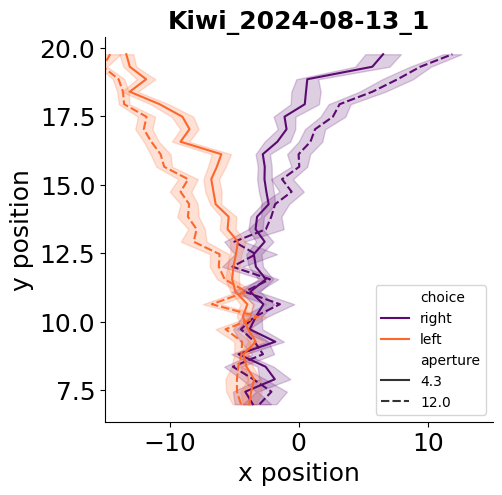

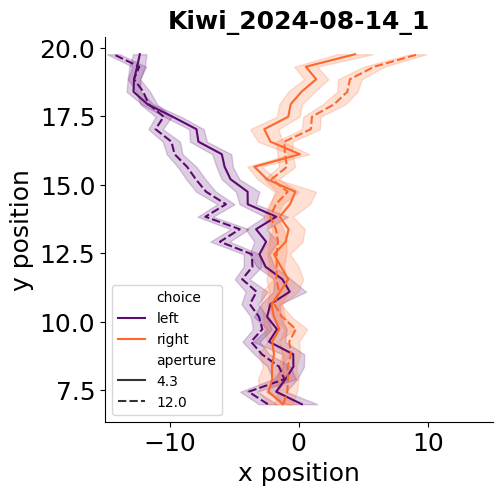

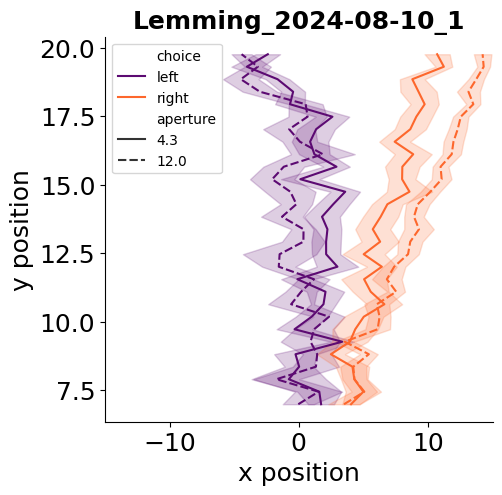

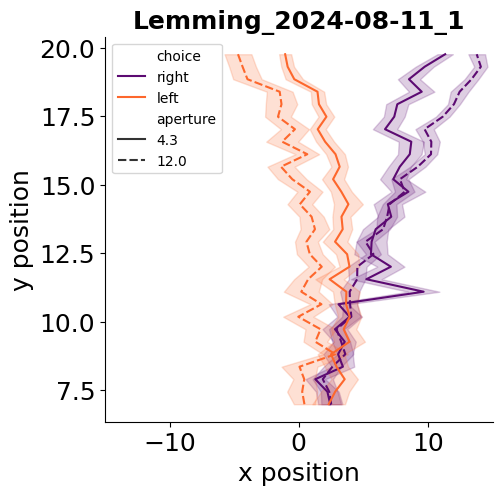

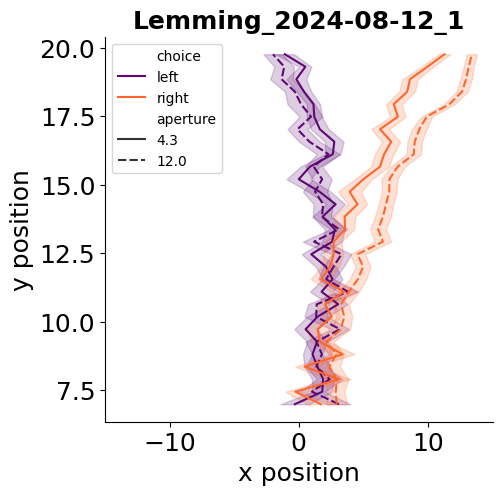

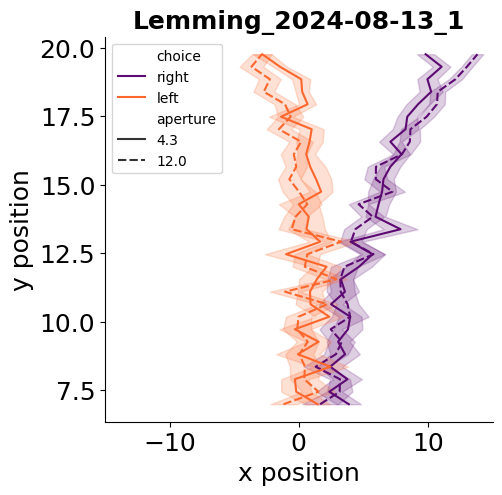

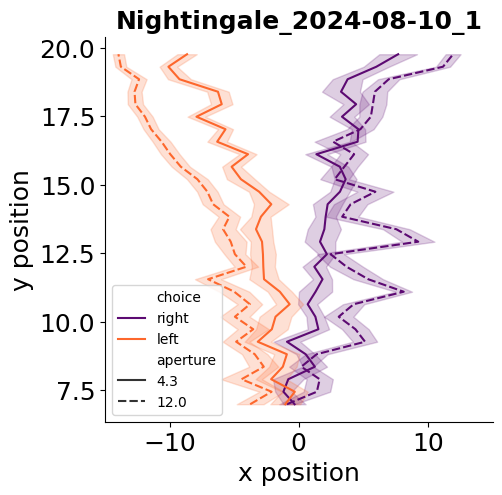

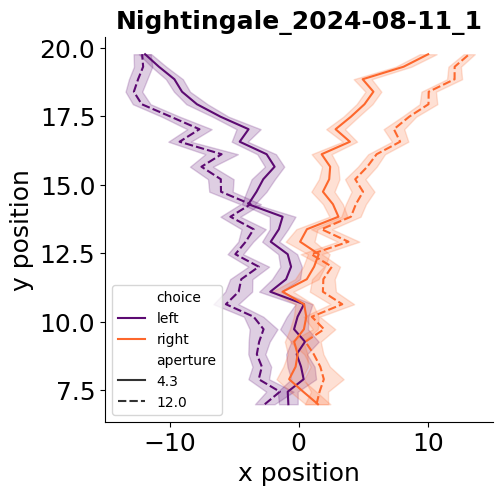

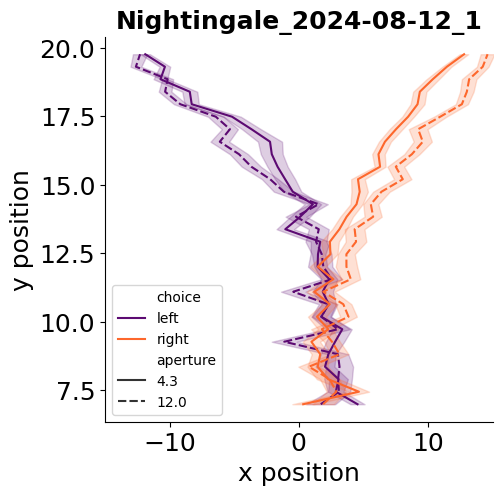

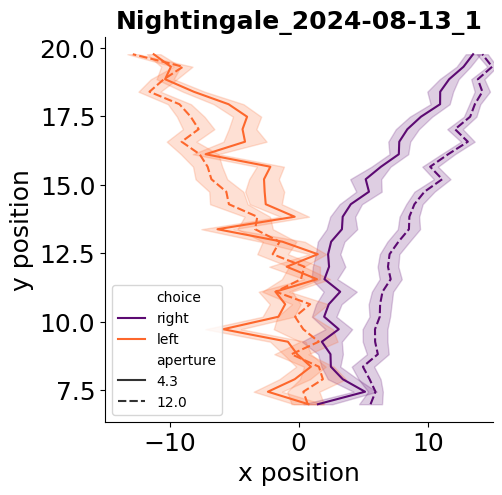

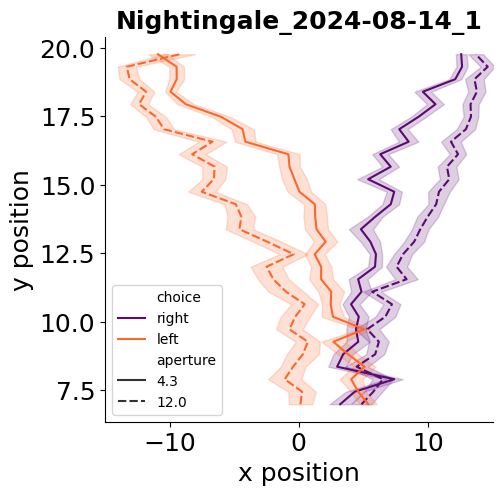

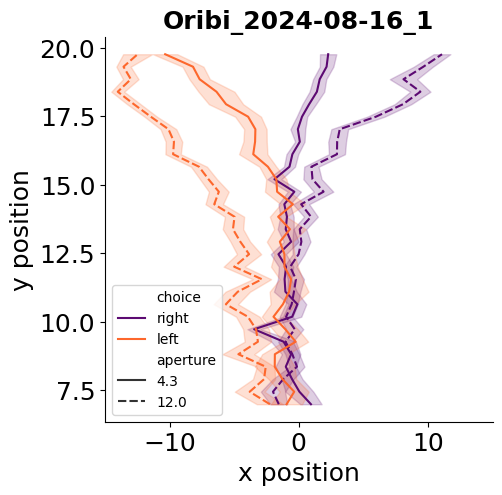

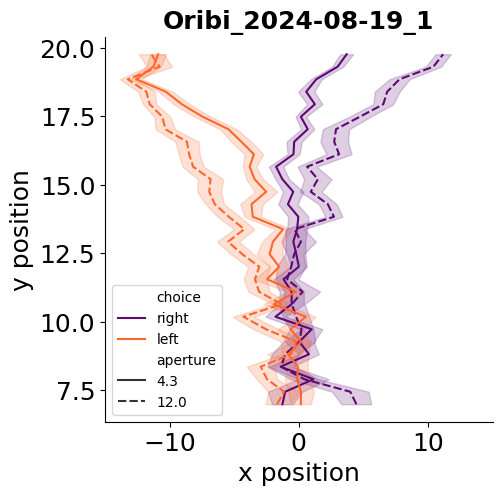

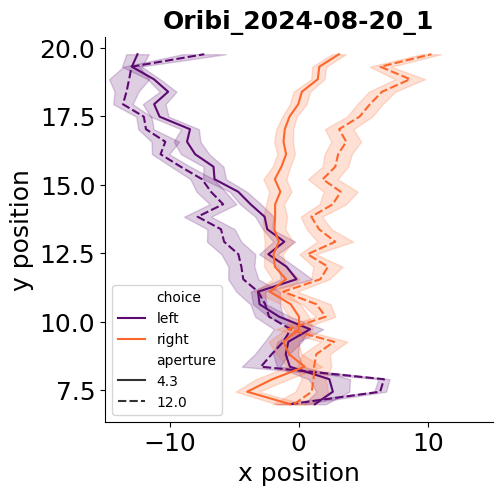

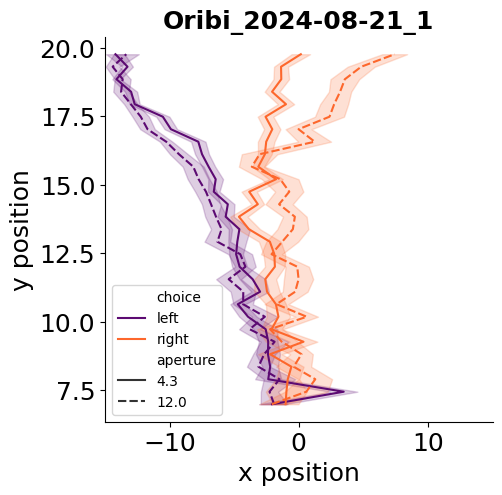

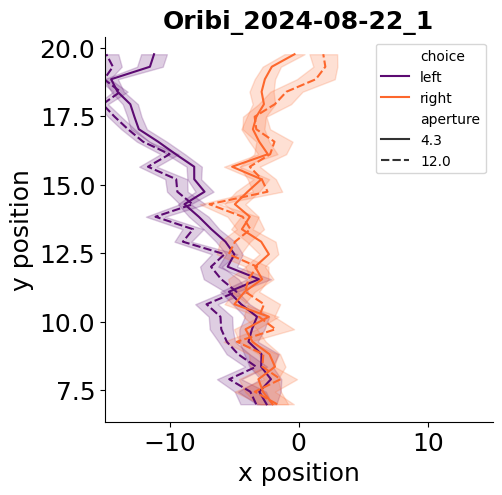

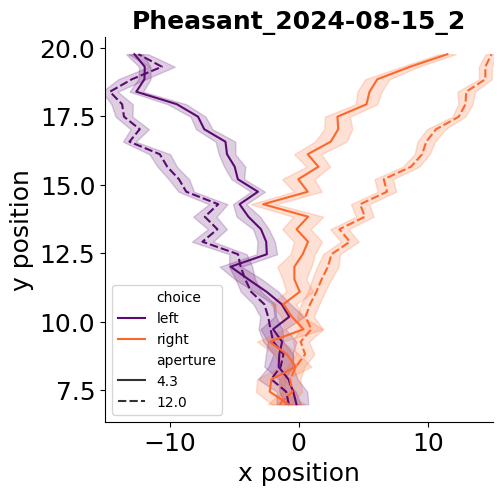

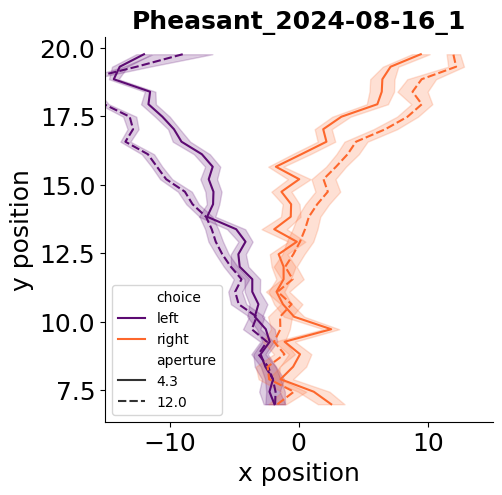

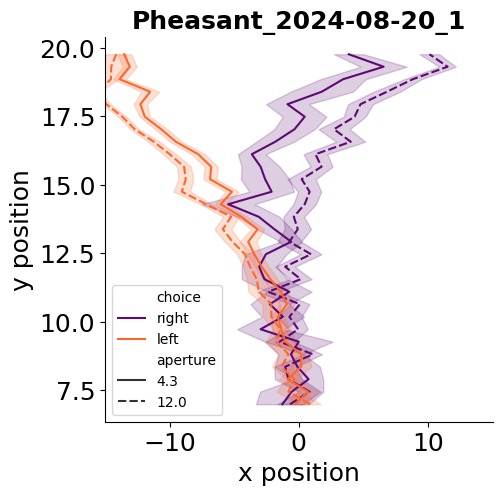

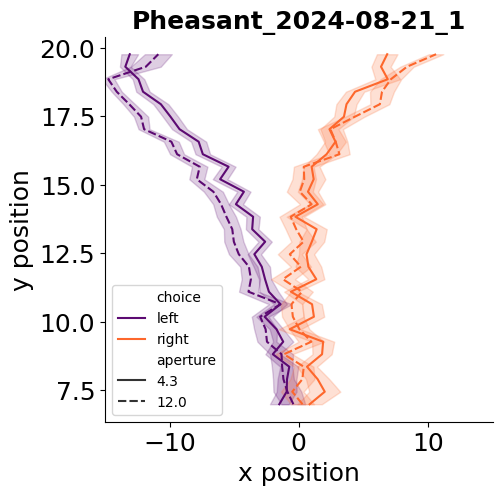

In [15]:
j_shaped = utils.create_bins(data=j_shaped.copy(), spatial_ybins=[6.75, 20, 30], label="y")

for d in j_shaped.dataset.unique():
    print(d)
    fig, ax = plt.subplots(1,1,figsize=(5,5))
    plotting.lineplot_flip_axis(
        data=j_shaped [j_shaped.dataset == d],
        x="bin_centers",
        y="x",
        hue="choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
        palette=plotting.colors_choice if len(mean_mouse.aperture.unique()) == 2 else "viridis",
        style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "choice",
        errorbar="se",
        ax=ax,
    )
    plt.title(d)
    plt.ylabel("y position")
    plt.xlabel("x position")
    plt.xlim(-15,15)
    plt.savefig(fig_save_path + str(d) + "_dual_occluder_aperture_mean_traj.svg", transparent=True)

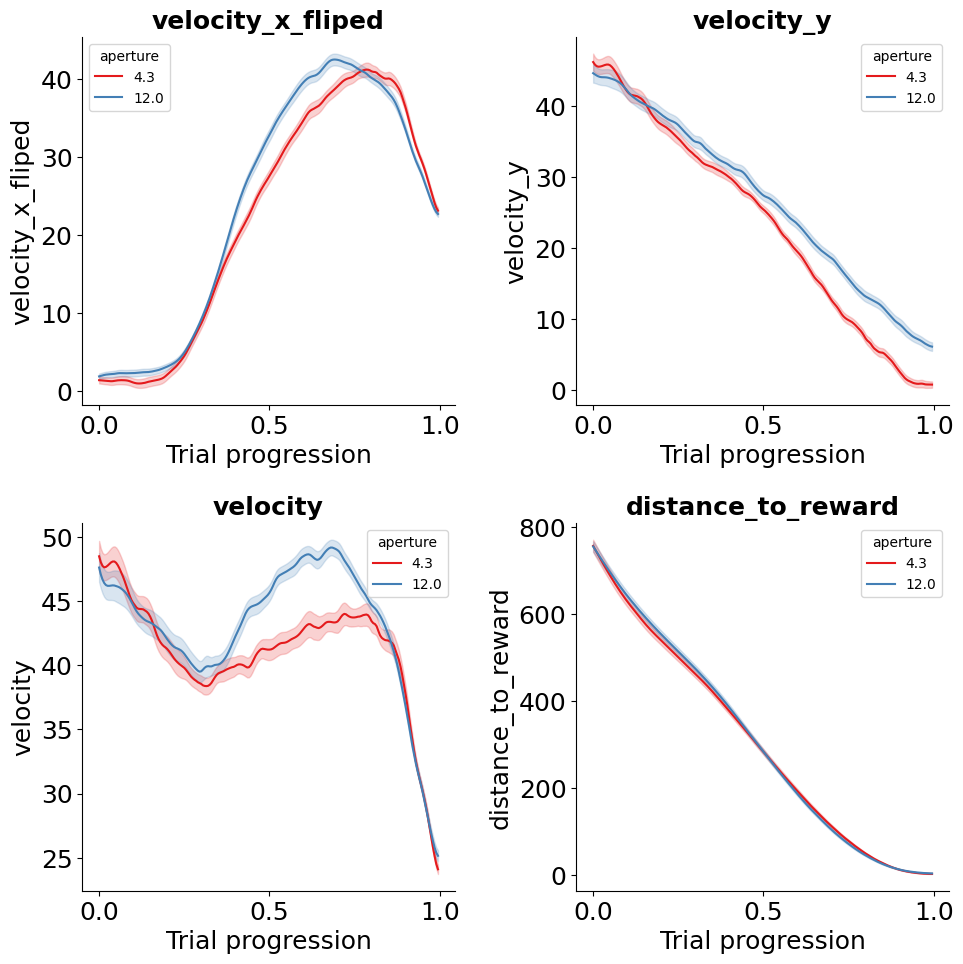

In [30]:
columns = [
    "y",
    "heading_dir",
    "head_angle",
    "trial_tortuosity",
    "trial_init_x",
    "trial_duration",
    "x",
    "norm_x",
    "trial_init_y",
    "aperture",
    "velocity",
    "velocity_x",
    "velocity_y",
    "acceleration_x",
    "heading_dir_velocity",
    "head_angle_velocity",
    "head_angle_acceleration",
    "trial_traj_path_length",
    "trial_rewarded",
    "heading_dir_acceleration",
    "norm_y",
    "flip_one_side",
    "distance_to_reward",
]

interpolated_j_shaped = utils.interpolate(
    j_shaped, n_points=200, value_columns=["trial_left_choice"] + columns
)
interpolated_j_shaped["trial_step"] = interpolated_j_shaped.groupby(
    ["session", "trial"], as_index=False).trial.cumcount()


interpolated_j_shaped["trial_length"] = interpolated_j_shaped["trial_step"] / 200
interpolated_j_shaped["heading_dir_sin"] = np.sin(np.deg2rad(interpolated_j_shaped.heading_dir))
interpolated_j_shaped["heading_dir_cos"] = np.sin(np.deg2rad(interpolated_j_shaped.heading_dir))
interpolated_j_shaped["velocity_x_fliped"] = (
    interpolated_j_shaped["velocity_x"] * interpolated_j_shaped["flip_one_side"]
)


mean_mouse_interp = interpolated_j_shaped.groupby(["session", "aperture", "trial_length"],as_index=False).mean(numeric_only=True)

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax = ax.flatten()
x_labels =  ["x velocity (cm/s)", "y velocity (cm/s)", "combined veloctiy (cm/s)"]

for i, label in enumerate(
    ["velocity_x_fliped", "velocity_y", "velocity", "distance_to_reward"]
):
    sns.lineplot(
        data=mean_mouse_interp,
        x="trial_length",
        y=label,
        palette=(
            plotting.colors_aperture[:2]
            if len(mean_mouse_interp.aperture.unique()) == 2
            else plotting.colors_aperture
        ),
        hue="aperture",
        # style="trial_L_choice",
        errorbar="se",
        ax=ax[i],
    )
    ax[i].set_title(f"{label}")
    ax[i].set_xlabel("Trial progression")
plt.tight_layout(pad=2)

/var/folders/xx/w02j3bzd5n549z3dmcg59ddw0000gn/T/ipykernel_34210/852385432.py:36: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


(0.0, 50.0)

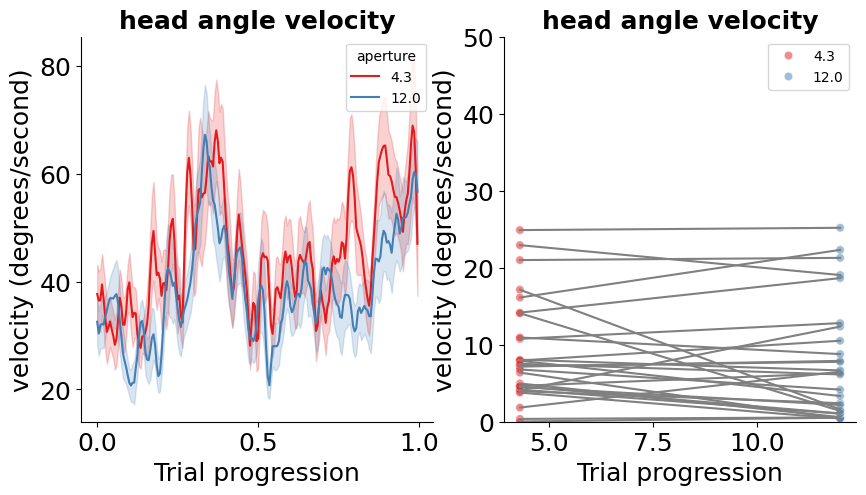

In [68]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
sns.lineplot(
        data=mean_mouse_interp,
        x="trial_length",
        y=abs(np.rad2deg(mean_mouse_interp.head_angle_velocity)),
        palette=(
            plotting.colors_aperture[:2]
            if len(mean_mouse_interp.aperture.unique()) == 2
            else plotting.colors_aperture
        ),
        hue="aperture",
        # style="trial_L_choice",
        errorbar="se",
        ax=ax[0],
    )
ax[0].set_title(f"head angle velocity")
ax[0].set_xlabel("Trial progression")
ax[0].set_ylabel("velocity (degrees/second)")


mean_mouse_trial_interp = mean_mouse_interp.groupby(["session", "aperture"],as_index=False).mean(numeric_only=True)
sns.scatterplot(
        data=mean_mouse_trial_interp,
        x="aperture",
        y=abs(np.rad2deg(mean_mouse_trial_interp.head_angle_velocity)),
        palette=(
            plotting.colors_aperture[:2]
            if len(mean_mouse_interp.aperture.unique()) == 2
            else plotting.colors_aperture
        ),
        hue="aperture",
        # style="trial_L_choice",
        alpha=0.5,
        ax=ax[1],
    )
sns.lineplot(
        data=mean_mouse_trial_interp,
        x="aperture",
        y=abs(np.rad2deg(mean_mouse_trial_interp.head_angle_velocity)),
        palette=(
            plotting.colors_aperture[:2]
            if len(mean_mouse_interp.aperture.unique()) == 2
            else plotting.colors_aperture
        ),
        units="session",
        color="grey",
        # style="trial_L_choice",
        estimator = None,
        ax=ax[1],
    )
ax[1].set_title(f"head angle velocity")
ax[1].set_xlabel("Trial progression")
ax[1].set_ylabel("velocity (degrees/second)")
ax[1].set_ylim(0,50)
ax[1].set_ylim(0,50)

In [69]:
columns = [
    "y",
    "heading_dir",
    "head_angle",
    "trial_tortuosity",
    "trial_init_x",
    "trial_duration",
    "x",
    "norm_x",
    "trial_init_y",
    "aperture",
    "velocity",
    "velocity_x",
    "velocity_y",
    "acceleration_x",
    "heading_dir_velocity",
    "trial_traj_path_length",
    "trial_rewarded",
    "heading_dir_acceleration",
    "norm_y",
    "flip_one_side",
    "distance_to_reward",
]

interpolated_j_shaped = utils.interpolate(
    j_shaped, n_points=200, value_columns=["trial_left_choice"] + columns
)
interpolated_j_shaped["trial_step"] = interpolated_j_shaped.groupby(
    ["session", "trial"], as_index=False).trial.cumcount()


interpolated_j_shaped["trial_length"] = interpolated_j_shaped["trial_step"] / 200
interpolated_j_shaped["heading_dir_sin"] = np.sin(np.deg2rad(interpolated_j_shaped.heading_dir))
interpolated_j_shaped["heading_dir_cos"] = np.sin(np.deg2rad(interpolated_j_shaped.heading_dir))
interpolated_j_shaped["velocity_x_fliped"] = (
    interpolated_j_shaped["velocity_x"] * interpolated_j_shaped["flip_one_side"]
)


In [76]:
model_labels = [
    "x",
    "y",
    "heading_dir_sin",
    "heading_dir_cos",
    "head_angle",
    "trial_tortuosity",
    "trial_duration",
    "trial_init_x",
    "trial_init_y",
    "trial_traj_path_length",
    "aperture",
    "trial_rewarded",
    "trial_length",
    "distance_to_reward",
]

In [77]:
def create_shuffled_trials(df, label_to_shuffle = "trial_left_choice"):
    trial_choices = df.groupby('trial')[label_to_shuffle].first().values

    # Shuffle these trial-level choices
    np.random.shuffle(trial_choices)

    # Create a dictionary of shuffled trial choices
    trial_choice_dict = dict(zip(df['trial'].unique(), trial_choices))

    # Assign the shuffled trial choices back to the DataFrame based on the trial number
    df [label_to_shuffle] = df['trial'].map(trial_choice_dict)
    return(df)

In [78]:
interpolated_j_shaped.keys()

Index(['time', 'trial_left_choice', 'y', 'heading_dir', 'head_angle',
       'trial_tortuosity', 'trial_init_x', 'trial_duration', 'x', 'norm_x',
       'trial_init_y', 'aperture', 'velocity', 'velocity_x', 'velocity_y',
       'acceleration_x', 'heading_dir_velocity', 'trial_traj_path_length',
       'trial_rewarded', 'heading_dir_acceleration', 'norm_y', 'flip_one_side',
       'distance_to_reward', 'session', 'trial', 'trial_step', 'trial_length',
       'heading_dir_sin', 'heading_dir_cos', 'velocity_x_fliped'],
      dtype='object')

In [79]:
interpolated_j_shaped_shuff = interpolated_j_shaped.groupby(["session"], as_index = False).apply(create_shuffled_trials)


In [80]:
df_model, coef = regression.predict_decision(
    df=interpolated_j_shaped, label=model_labels, per_mouse=True
    )

df_model_shuff, coef_shuff = regression.predict_decision(
    df=interpolated_j_shaped_shuff, label=model_labels, per_mouse=True
    )


/Users/thomassainsbury/opt/anaconda3/envs/djvr4mice/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/thomassainsbury/opt/anaconda3/envs/djvr4mice/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://sciki

/var/folders/xx/w02j3bzd5n549z3dmcg59ddw0000gn/T/ipykernel_34210/1378046083.py:5: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.lineplot(
/var/folders/xx/w02j3bzd5n549z3dmcg59ddw0000gn/T/ipykernel_34210/1378046083.py:17: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.lineplot(


Text(0.5, 0, 'Trial progression')

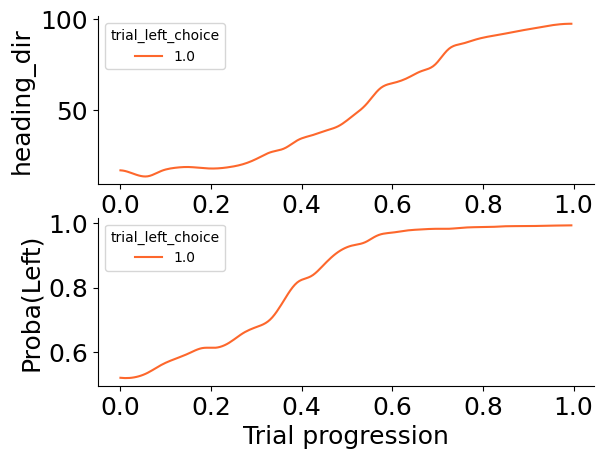

In [95]:
fig, ax = plt.subplots(2, 1)
trials = range(57, 60)
group = df_model[(df_model.trial.isin(trials)) & (df_model.session == dual_occuder[9]["dataset"])]

sns.lineplot(
    data=group,
    x="trial_length",
    y="heading_dir",
    hue="trial_left_choice",
    errorbar=None,
    estimator=None,
    units="trial",
    palette=[plotting.colors_choice[1], plotting.colors_choice[0]],
    ax=ax[0],sort=False,
)

sns.lineplot(
    data=group,
    x="trial_length",
    y="proba_left",
    hue="trial_left_choice",
    errorbar=None,
    estimator=None,
    units="trial",
    palette=[plotting.colors_choice[1], plotting.colors_choice[0]],
    ax=ax[1],sort=False,
)
ax[1].set_ylabel("Proba(Left)")
ax[1].set_xlabel("Trial progression")

In [ ]:
mean_mouse = df_model.groupby(["session", "aperture", "trial_length"]).mean(numeric_only=True)
mean_mouse_model_shuff =  df_model_shuff.groupby(["session", "aperture", "trial_length"]).mean(numeric_only=True)

In [ ]:
sns.lineplot(
    data=group [group.trial == group.trial.unique()[trial]],
    x="y",
    y="heading_dir",
)

ax[1].set_ylabel("y")
ax[1].set_xlabel("x")

In [ ]:
fig, ax = plt.subplots(2,1)
trial = 13
ax[0].plot(big_df ["heading_dir"][(big_df.trial == trial) & (big_df.dataset == big_df.dataset.unique()[0])]-90)
ax[0].plot(big_df ["head_dir"][(big_df.trial == trial) & (big_df.dataset == big_df.dataset.unique()[0])])
ax[1].scatter(big_df ["x"][(big_df.trial == trial) & (big_df.dataset == big_df.dataset.unique()[0])],
              big_df ["y"][(big_df.trial == trial) & (big_df.dataset == big_df.dataset.unique()[0])],
              c=big_df ["heading_dir"][(big_df.trial == trial) & (big_df.dataset == big_df.dataset.unique()[0])])

In [ ]:
trials = range(45, 50)
group = df_model[(df_model.trial.isin(trials)) & (df_model.session == dual_occuder[2]["dataset"])]

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(20, 5))

mean_mouse = df_model.groupby(["session", "aperture", "trial_length"]).mean(
    numeric_only=True
)

mean_mouse_per_choice = df_model.groupby(
    ["session", "trial_left_choice", "aperture", "trial_length"]
).mean(numeric_only=True)

# Accuracy
sns.lineplot(
    ax=ax[0],
    data=mean_mouse,
    y="accuracy",
    x="trial_length",
    hue="aperture",
    palette=(
        plotting.colors_aperture[:2] if len(df_model.aperture.unique()) == 2 else colors_aperture
    ),
    errorbar="se",
)
percentile = np.percentile(mean_mouse_model_shuff.accuracy, 95)

ax[0].hlines(xmin=0, xmax=1, y=0.5, linestyles="dashed", color="k")
ax[0].hlines(xmin=0, xmax=1, y=percentile, linestyles="dashed", color="grey")
ax[0].set_ylim(0.4, 1)

# P(Left)
sns.lineplot(
    ax=ax[1],
    data=mean_mouse_per_choice,
    y="proba_left",
    x="trial_length",
    hue="trial_left_choice" if len(df_model.aperture.unique()) == 2 else "aperture",
    style="aperture" if len(df_model.aperture.unique()) == 2 else "trial_left_choice",
    palette=(
        [plotting.colors_choice[1], plotting.colors_choice[0]]
        if len(df_model.aperture.unique()) == 2
        else "viridis"
    ),
)
ax[1].hlines(xmin=0, xmax=1, y=0.5, linestyles="dashed", color="k")
ax[1].hlines(xmin=0, xmax=1, y=0.8, linestyles="dotted", color="grey")
ax[1].hlines(xmin=0, xmax=1, y=0.2, linestyles="dotted", color="grey")

# Logits of the regression
ax[2].bar(
    np.arange(coef[:, 1:].shape[1]),
    np.mean(coef[:, 1:], axis=0),
    yerr=stats.sem(coef[:, 1:], axis=0),
)

#ax[2].set_xticks(list(np.arange(coef[:, 1:].shape[1])), model_labels, rotation=90)

plt.tight_layout(pad=1.0)
plt.show()

In [ ]:
np.percentile(mean_mouse_model_shuff.accuracy, 95)

In [ ]:
decision_points = regression.find_decision_point(df_model, threshold_uncertainty=0.3)


In [ ]:

fig, ax = plt.subplots(1, 1, figsize=(3, 5))
plotting.plot_decision_point(decision_points, label_parameter="y",  ax=ax)
plt.ylim(0,25)
plt.xlim(1.5,-0.5)
plt.xticks([1,0], ["No Occ.", "Occ."])